In [ ]:
# import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# load the stock market dataset
data = {
    'stock_name': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JNJ', 'V', 'PG', 'DIS', 'NFLX'],
    'Annual_Return': [30.2, 27.5, 25.0, 40.3, 50.1, 15.2, 12.3, 10.8, 22.7, 35.6],
    'Volatility': [20.5, 18.7, 21.0, 25.5, 30.2, 15.1, 14.2, 13.5, 17.0, 22.3],
    'Market_Cap': [2.5, 2.0, 1.8, 1.7, 1.0, 0.4, 0.5, 0.35, 0.3, 0.15],
}
df = pd.DataFrame(data)
print ("step2; loaded Dataset")
print(df)

step2; loaded Dataset
  stock_name  Annual_Return  Volatility  Market_Cap
0       AAPL           30.2        20.5        2.50
1       MSFT           27.5        18.7        2.00
2      GOOGL           25.0        21.0        1.80
3       AMZN           40.3        25.5        1.70
4       TSLA           50.1        30.2        1.00
5        JNJ           15.2        15.1        0.40
6          V           12.3        14.2        0.50
7         PG           10.8        13.5        0.35
8        DIS           22.7        17.0        0.30
9       NFLX           35.6        22.3        0.15


In [ ]:
X=df[['Annual_Return','Volatility','Market_Cap']]
scalar = StandardScaler()
x_std = scalar.fit_transform(X)
print ("step3; standardized the dataset")
print(x_std) # Changed X_scalar to x_std

step3; standardized the dataset
[[ 0.26961631  0.13971527  1.76341745]
 [ 0.04424045 -0.21955257  1.14683793]
 [-0.16444091  0.23951189  0.90020611]
 [ 1.11268898  1.13768149  0.77689021]
 [ 1.93071988  2.07576974 -0.08632113]
 [-0.98247181 -0.93808825 -0.82621657]
 [-1.22454218 -1.11772217 -0.70290066]
 [-1.34975099 -1.25743744 -0.88787452]
 [-0.35642775 -0.55886108 -0.94953248]
 [ 0.72036803  0.49898311 -1.13450633]]


step4; calculated WCSS


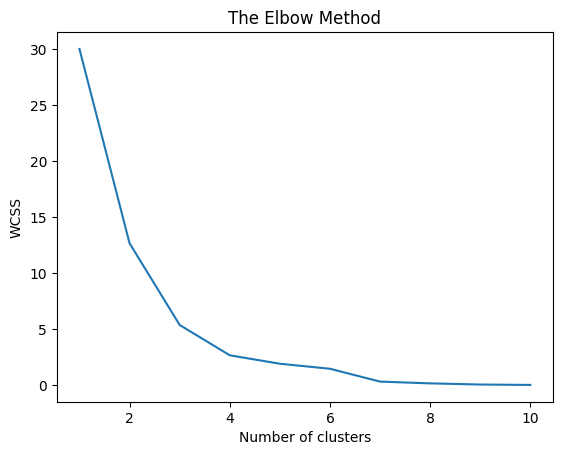


STEP-4: K-Means Clustering Complete with 3 Clusters
  stock_name  Annual_Return  Volatility  Market_Cap  Cluster
0       AAPL           30.2        20.5        2.50        2
1       MSFT           27.5        18.7        2.00        2
2      GOOGL           25.0        21.0        1.80        2
3       AMZN           40.3        25.5        1.70        0
4       TSLA           50.1        30.2        1.00        0
5        JNJ           15.2        15.1        0.40        1
6          V           12.3        14.2        0.50        1
7         PG           10.8        13.5        0.35        1
8        DIS           22.7        17.0        0.30        1
9       NFLX           35.6        22.3        0.15        0


In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_std)
    wcss.append(kmeans.inertia_)
print ("step4; calculated WCSS")
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
# The variable X_scaled was not defined. Changing to x_std which contains the standardized data
df['Cluster'] = kmeans.fit_predict(x_std)
# Display cluster assignments
print(f"\nSTEP-4: K-Means Clustering Complete with {optimal_clusters} Clusters")
print(df)

In [ ]:
sil_score = silhouette_score(x_std, df['Cluster'])
print(f"Silhouette Score: {sil_score:.2f}" )

Silhouette Score: 0.54


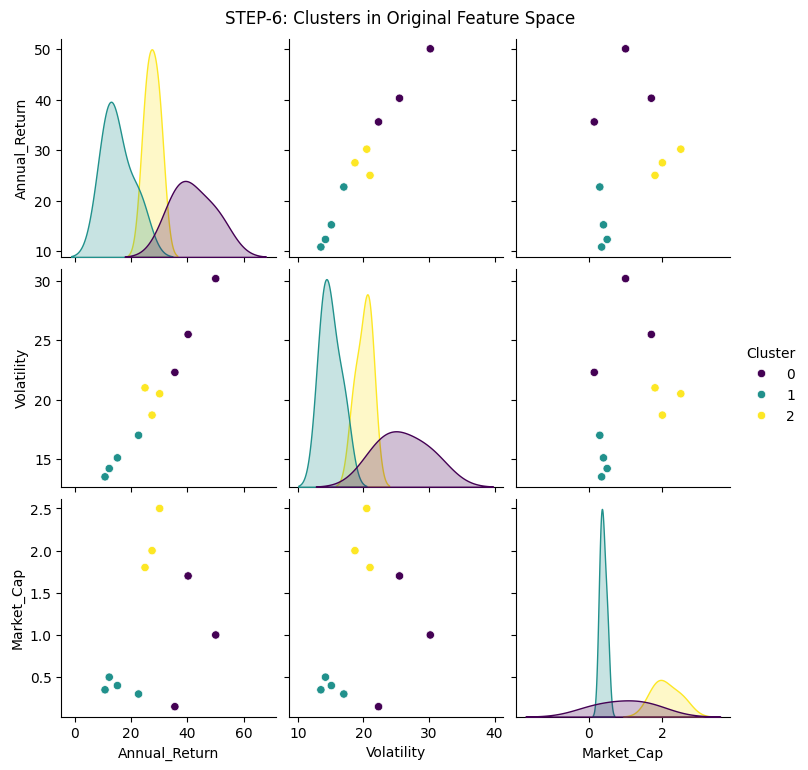

In [ ]:
sns.pairplot(df, vars=['Annual_Return', 'Volatility', 'Market_Cap'], hue='Cluster', palette='viridis')
plt.suptitle("STEP-6: Clusters in Original Feature Space", y=1.02)
plt.show()

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_std)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
# Display explained variance ratio
print(f"\nSTEP-7: PCA Applied - Explained Variance: {pca.explained_variance_ratio_.sum():.2f}")




STEP-7: PCA Applied - Explained Variance: 0.99


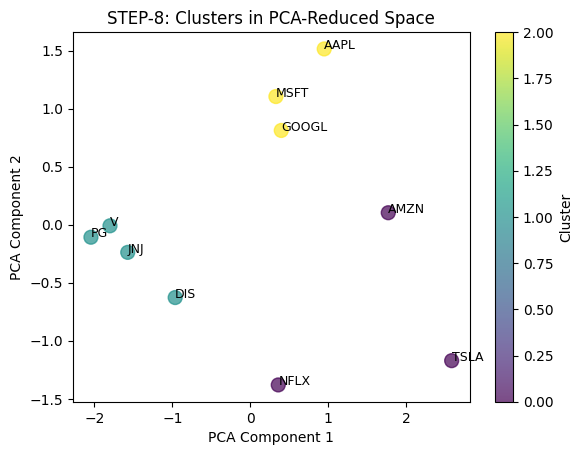

In [ ]:
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis', s=100, alpha=0.7) #CMAP = plasma,inferno,magma,cividis,Greens,Blues,Purples
for i, txt in enumerate(df['stock_name']): # Changed 'Stock' to 'stock_name'
  plt.annotate(txt, (df['PCA1'][i], df['PCA2'][i]), fontsize=9)
plt.title("STEP-8: Clusters in PCA-Reduced Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster") # Moved colorbar outside the loop
plt.show()

# u can skip it for exam


STEP-9: Cluster Characteristics Summary
         Annual_Return  Volatility  Market_Cap
Cluster                                       
0            42.000000   26.000000      0.9500
1            15.250000   14.950000      0.3875
2            27.566667   20.066667      2.1000


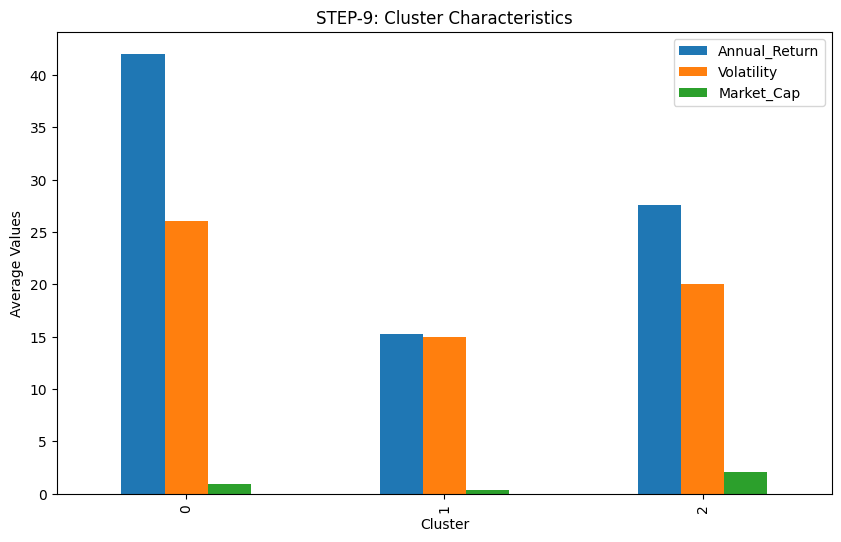

In [ ]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)[['Annual_Return', 'Volatility', 'Market_Cap']]
print("\nSTEP-9: Cluster Characteristics Summary")
print(cluster_summary)
# Bar plot of cluster characteristics
cluster_summary.plot(kind='bar', figsize=(10, 6))
plt.title("STEP-9: Cluster Characteristics")
plt.xlabel("Cluster")
plt.ylabel("Average Values")
plt.legend(loc="upper right")
plt.show()